##### We'll start off by importing and observing the database

In [4]:
import pandas as pd
data_csv = pd.read_csv("../Phase1_Tanisha/bangalore-wards-2019-3-OnlyWeekdays-HourlyAggregate.csv")
data_csv.head()

,sourceid,dstid,hod,mean_travel_time,standard_deviation_travel_time,geometric_mean_travel_time,geometric_standard_deviation_travel_time
0,55,111,8,2026.76,639.03,1942.16,1.33
1,22,25,13,770.07,378.42,700.64,1.51
2,163,16,14,3151.78,674.41,3092.38,1.21
3,162,26,14,3093.64,613.05,3046.00,1.18
4,23,15,13,2835.28,527.41,2789.81,1.19


##### For now, we'll only need the first 3 columns.                                 We also need to corelate source and destination ID, for which we'll import the corresponding JSON

In [9]:
import geopandas as gpd
wards = gpd.read_file("bangalore_wards.json")
wards.shape

(198, 5)

In [7]:
import json
import folium
import os
from shapely.geometry import shape
with open('bangalore_wards.json', 'r') as f:
    data = json.load(f)
    # This prints the keys of the first ward it finds
    print("Your GeoJSON properties look like this:")
    print(data['features'][0]['properties'])

Your GeoJSON properties look like this:
{'WARD_NO': '2', 'WARD_NAME': 'Chowdeswari Ward', 'MOVEMENT_ID': '1', 'DISPLAY_NAME': 'Unnamed Road, Bengaluru'}


##### Since our CSV has 198 rows and we wanna analyse it all, I'm increasing the max rows that can be displayed at once

In [3]:
pd.set_option('display.max_rows', 200)

In [4]:
# Convert the ID in the GeoDataFrame to an integer to match the CSV
wards['MOVEMENT_ID'] = wards['MOVEMENT_ID'].astype(int)
wards.sort_values(by='WARD_NAME')

,WARD_NO,WARD_NAME,MOVEMENT_ID,DISPLAY_NAME,geometry
7,56,A Narayanapura,8,"100 2nd Cross Road, A Narayanapura, Mottappa C...","MULTIPOLYGON (((77.6772 13.00056, 77.67665 13...."
154,147,Adugodi,155,"900 Adugodi Main Road, Audugodi Police Quarter...","MULTIPOLYGON (((77.61875 12.94357, 77.61874 12..."
90,114,Agaram,91,"Intermediate Ring Road, Ejipura, Bengaluru","MULTIPOLYGON (((77.62616 12.97376, 77.62737 12..."
111,105,Agrahara Dasarahalli,112,"0 17th A Cross Road, Agrahara Dasarahalli, Raj...","MULTIPOLYGON (((77.54243 12.98568, 77.54242 12..."
184,196,Anjanapura,185,"Anjanapura 80 Feet Road, Anjanapura Village, A...","MULTIPOLYGON (((77.58204 12.86006, 77.58049 12..."
178,193,Arakere,179,"100 Hulimavu Lake Road, Krishna Layout, Hulima...","MULTIPOLYGON (((77.59995 12.8673, 77.59995 12...."
44,35,Aramane Nagara,45,"94, RMV 2nd Stage, Ashwath Nagar, Armane Nagar...","MULTIPOLYGON (((77.58 13.02653, 77.58007 13.02..."
121,132,Attiguppe,122,"0 2nd Cross Road, Basaveshawara HBCS Layout 2n...","MULTIPOLYGON (((77.53469 12.96434, 77.53467 12..."
1,3,Atturu,2,"9th Cross Bhel Layout, Adityanagar, Vidyaranya...","MULTIPOLYGON (((77.56862 13.12705, 77.57064 13..."
132,141,Azad Nagar,133,"165, Vittal Nagar, Kasthuriba Nagar, Azad Naga...","MULTIPOLYGON (((77.55449 12.95811, 77.55528 12..."


##### We'll consider ward number 163 --> Katriguppe	

In [5]:
# Filter for 9 AM and destination ward 163
katriguppe_id = wards[wards['WARD_NO'] == '163']['MOVEMENT_ID'].iloc[0]
filtered_travel = data_csv[(data_csv['dstid'] == katriguppe_id) & (data_csv['hod'] == 9)]

In [6]:
# Join the map (wards) with the travel times (filtered_travel)
# sourceid in the CSV matches MOVEMENT_ID in the JSON
merged_gdf = wards.merge(filtered_travel, left_on='MOVEMENT_ID', right_on='sourceid')

Standard GPS coordinates (Latitude/Longitude) are measured in degrees. You can't calculate square kilometers from degrees accurately because degrees get "smaller" as you move away from the equator. By converting to UTM Zone 43N, we switch the math to a metric grid, allowing Python to calculate the exact area in square meters.

In [7]:
# Project the merged data first 
merged_gdf = merged_gdf.to_crs(epsg=32643)

In [8]:
# Filter for travel times <= 30 minutes (1800 seconds)
isochrone_30min = merged_gdf[merged_gdf['mean_travel_time'] <= 1800]

# Dissolve all the ward polygons into one single geometry
isochrone_shape = isochrone_30min.dissolve()

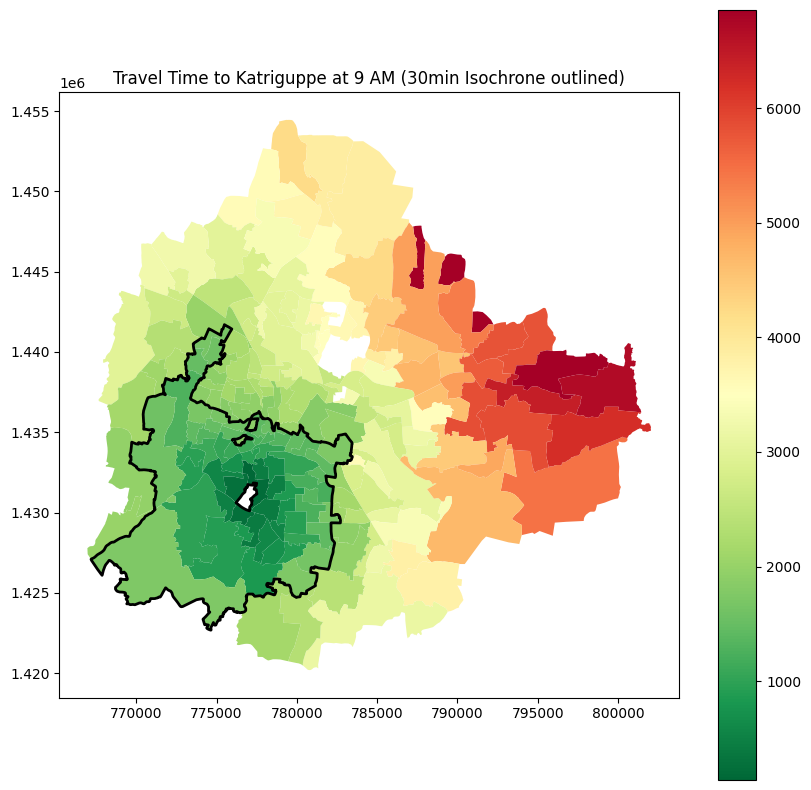

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
merged_gdf.plot(column='mean_travel_time', cmap='RdYlGn_r', legend=True, ax=ax)
isochrone_shape.boundary.plot(ax=ax, color='black', linewidth=2)
plt.title("Travel Time to Katriguppe at 9 AM (30min Isochrone outlined)")
plt.show()

In [10]:
# Calculate Area
# .area returns square meters; divide by 1,000,000 for sq km
total_area_km2 = isochrone_shape.area.sum() / 1_000_000
print(f"Total area: {total_area_km2:.2f} sq km")

Total area: 146.67 sq km


#### 1. Colour Scheme
Green represents "Good" and Red represents "Bad." For travel times:

• Green: Low travel time (you are close/fast).

• Yellow: Moderate travel time.

• Red: High travel time (you are far/stuck in traffic).

#### 2. Isochrone Map

Shows all points that can be reached from a specific center within a certain timeframe.

• Unlike a simple radius circle (which measures "as the crow flies"), an isochrone follows the actual road network and traffic patterns.

• In your map, the "30-minute Isochrone" is the specific boundary where the color transitions from "reachable" to "too far."

#### 3. Why dissolve()?

The original data is split into individual "Wards" (neighborhoods). If five wards are all within 30 minutes, dissolve() melts their internal borders away, leaving you with one clean "blob" representing the total reachable zone.

** The "holes" or white spots inside the map usually represent areas where Uber had no data for that specific hour or where the ward geometry didn't join correctly (often due to small topological gaps). **

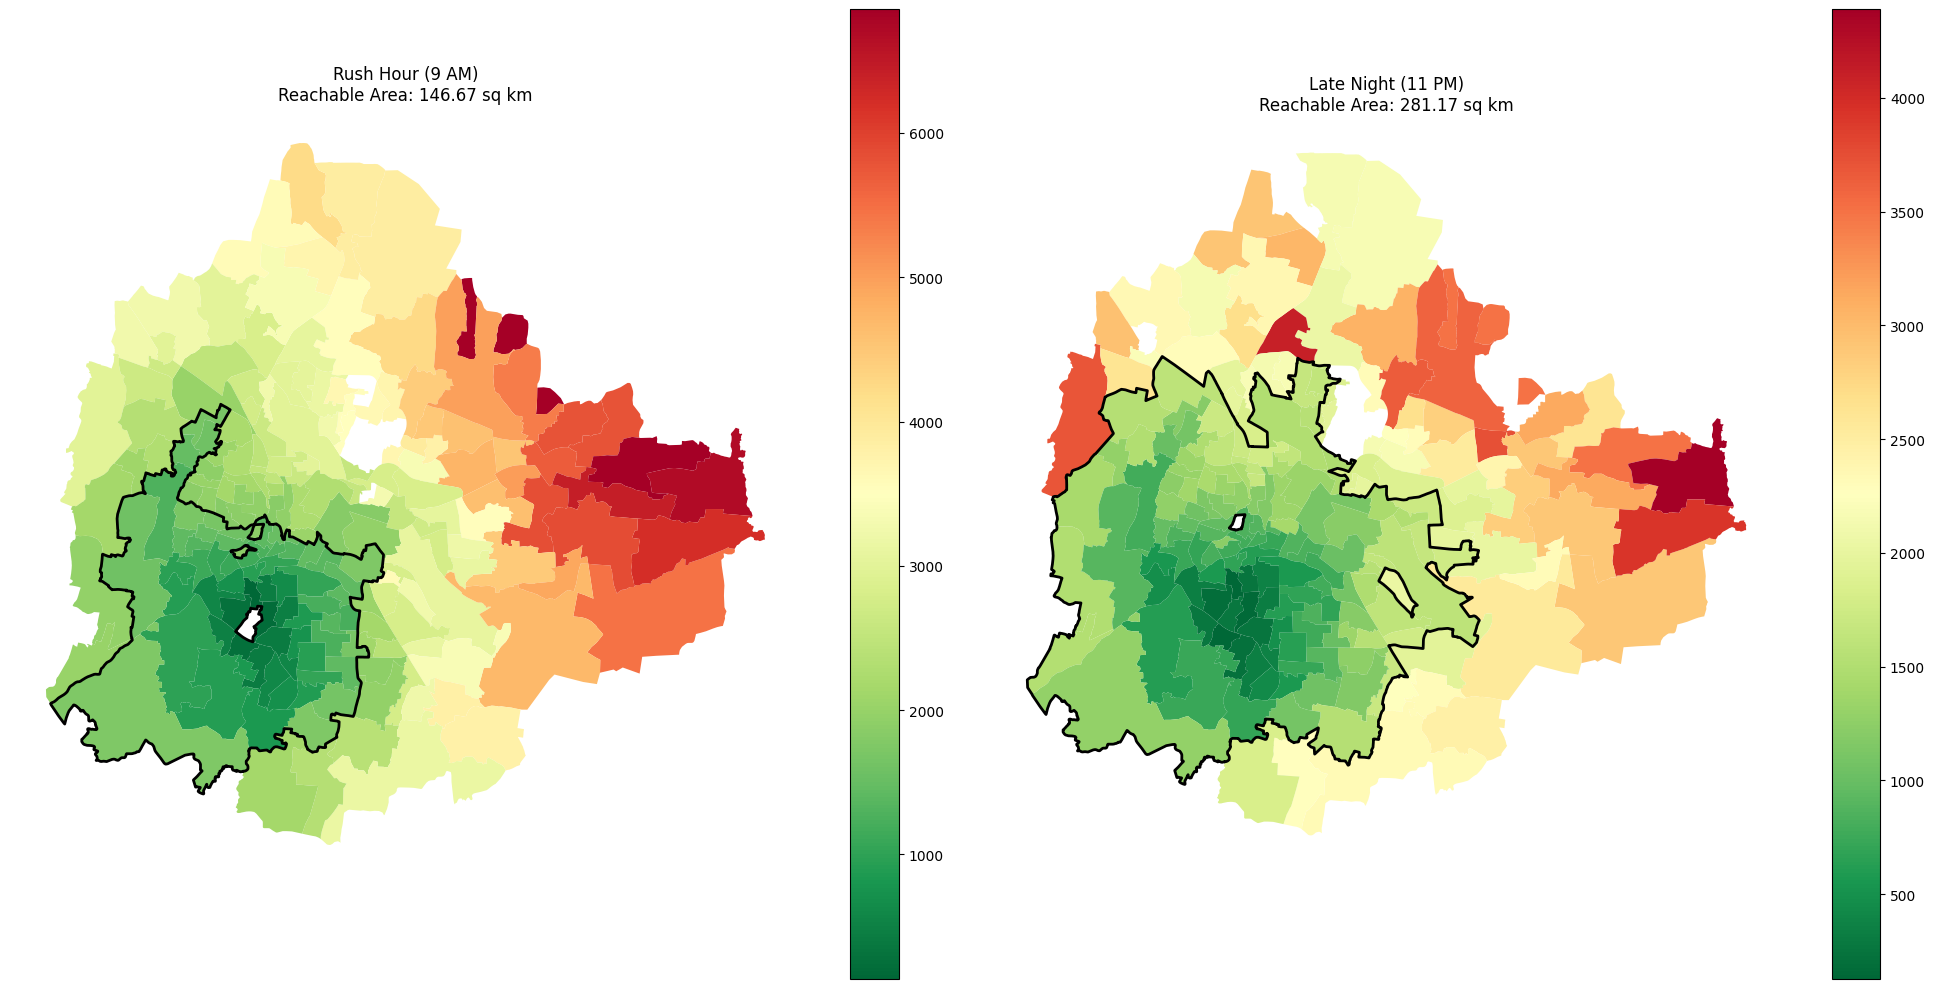

In [11]:
# Create a list for the two times we want to compare
hours = [9, 23] # 9 AM and 11 PM
titles = ['Rush Hour (9 AM)', 'Late Night (11 PM)']

target_id = wards[wards['WARD_NO'] == '163']['MOVEMENT_ID'].iloc[0] # CHange ward number to change target

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, hour in enumerate(hours):
    # 1. Filter data for the specific hour
    temp_filtered = data_csv[(data_csv['dstid'] == target_id) & (data_csv['hod'] == hour)]
    
    # 2. Merge and Project
    temp_merged = wards.merge(temp_filtered, left_on='MOVEMENT_ID', right_on='sourceid')
    temp_merged = temp_merged.to_crs(epsg=32643)
    
    # 3. Create and Dissolve Isochrone
    temp_isochrone = temp_merged[temp_merged['mean_travel_time'] <= 1800].dissolve()
    
    # 4. Calculate Area
    area = temp_isochrone.area.sum() / 1_000_000
    
    # 5. Plot on the respective subplot
    temp_merged.plot(column='mean_travel_time', cmap='RdYlGn_r', ax=axes[i], legend=True)
    temp_isochrone.boundary.plot(ax=axes[i], color='black', linewidth=2)
    
    axes[i].set_title(f"{titles[i]}\nReachable Area: {area:.2f} sq km")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

##### Here, we've chosen 9AM and 11PM. But what if we want to analyse the extremes? The highest and lowest congestion times and THEN compare to obtain the 'Traffic Opportunity Cost'

The most congested hour is: 18:00 with an average of 52.14 mins
The least congested hour is: 2:00 with an average of 19.21 mins


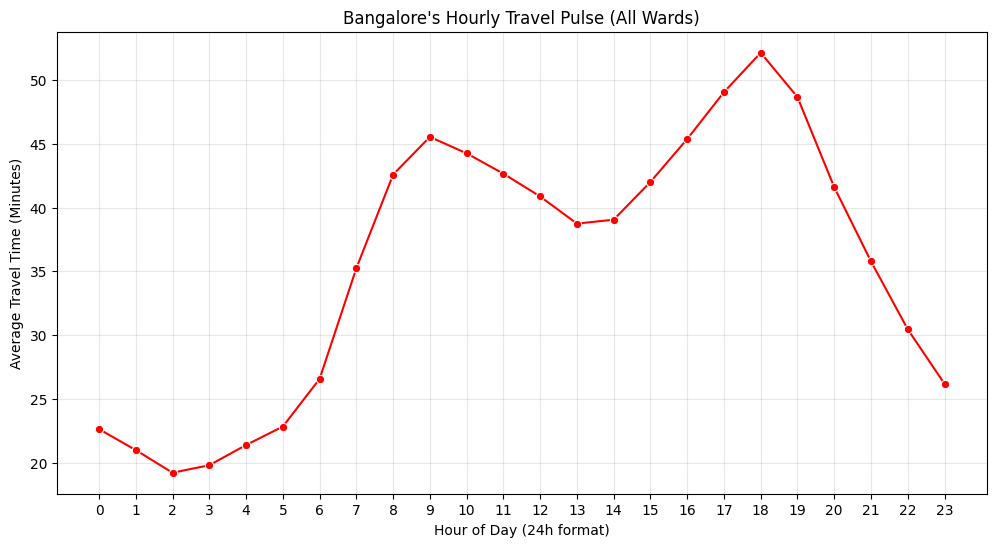

In [12]:
# 1. Calculate the city-wide average travel time for every hour
hourly_pulse = data_csv.groupby('hod')['mean_travel_time'].mean() / 60  # Convert to minutes

# 2. Find the extremes
worst_hour = hourly_pulse.idxmax()
best_hour = hourly_pulse.idxmin()

print(f"The most congested hour is: {worst_hour}:00 with an average of {hourly_pulse.max():.2f} mins")
print(f"The least congested hour is: {best_hour}:00 with an average of {hourly_pulse.min():.2f} mins")

# 3. Plot the "Bangalore Pulse"
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_pulse.index, y=hourly_pulse.values, marker='o', color='red')

plt.title("Bangalore's Hourly Travel Pulse (All Wards)")
plt.xlabel("Hour of Day (24h format)")
plt.ylabel("Average Travel Time (Minutes)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

##### This is for all wards in Bangalore. The traffic seems to be at an all time high at around 6PM (18H) and lowest at around 2AM

##### Now, specific to one ward

For Ward 163:
Worst time to arrive: 18:00 (49.65 mins avg)
Best time to arrive: 3:00 (18.68 mins avg)


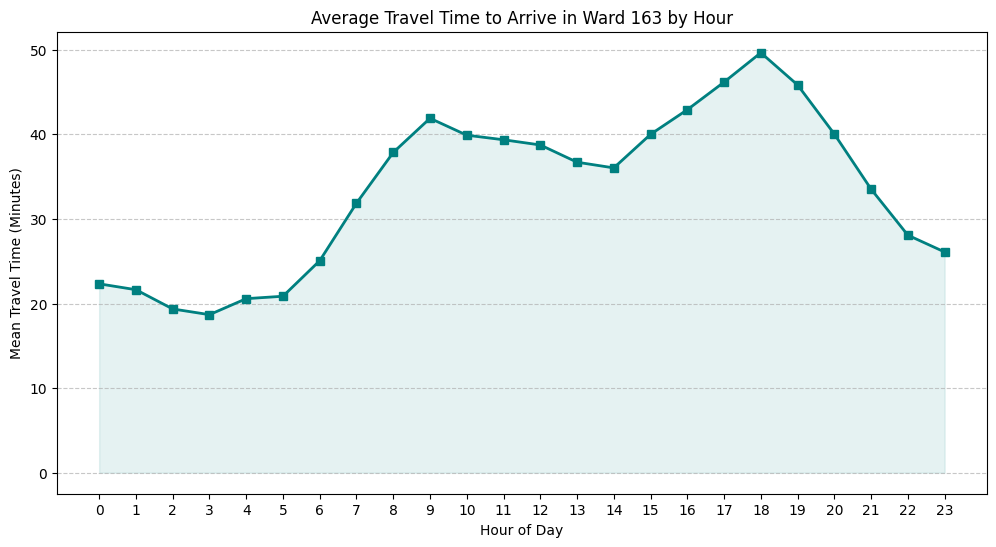

In [13]:
# 1. Filter for only trips DESTINED for your ward (Katriguppe)
target_ward_no = 163 # This is for Katriguppe, change as per need
ward_specific_data = data_csv[data_csv['dstid'] == target_id]

# 2. Group by hour and calculate mean travel time
ward_hourly_pulse = ward_specific_data.groupby('hod')['mean_travel_time'].mean() / 60

# 3. Identify the best and worst hours for YOUR ward
worst_ward_hour = ward_hourly_pulse.idxmax()
best_ward_hour = ward_hourly_pulse.idxmin()

print(f"For Ward {target_ward_no}:")
print(f"Worst time to arrive: {worst_ward_hour}:00 ({ward_hourly_pulse.max():.2f} mins avg)")
print(f"Best time to arrive: {best_ward_hour}:00 ({ward_hourly_pulse.min():.2f} mins avg)")

# 4. Plot the results
plt.figure(figsize=(12, 6))
plt.plot(ward_hourly_pulse.index, ward_hourly_pulse.values, color='teal', linewidth=2, marker='s')
plt.fill_between(ward_hourly_pulse.index, ward_hourly_pulse.values, color='teal', alpha=0.1)

plt.title(f"Average Travel Time to Arrive in Ward {target_ward_no} by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Travel Time (Minutes)")
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Another permutation: Which area has most traffic at a particular hour

In [14]:
# 1. Filter the whole dataset for 9 AM
hour_chosen = 18
rush_hour_data = data_csv[data_csv['hod'] == hour_chosen]

# 2. Calculate the average time it takes to reach EACH ward
# We group by 'dstid' (Destination)
ward_accessibility = rush_hour_data.groupby('dstid')['mean_travel_time'].mean().reset_index()

# 3. Sort them
worst_wards = ward_accessibility.sort_values(by='mean_travel_time', ascending=False).head(5)
best_wards = ward_accessibility.sort_values(by='mean_travel_time', ascending=True).head(5)

# 4. Link back to names for readability
# (Assuming 'wards' GeoDataFrame is loaded and IDs are integers)
worst_named = worst_wards.merge(wards[['MOVEMENT_ID', 'WARD_NAME']], left_on='dstid', right_on='MOVEMENT_ID')
print(f"Top 5 Hardest Wards to reach at {hour_chosen}H :")
print(worst_named[['WARD_NAME', 'mean_travel_time']])

Top 5 Hardest Wards to reach at 18H :
         WARD_NAME  mean_travel_time
0         Kadugodi       5009.035743
1          Hagadur       4960.078606
2      Singasandra       4547.280339
3         Varthuru       4536.182989
4  Mangammanapalya       4476.003202


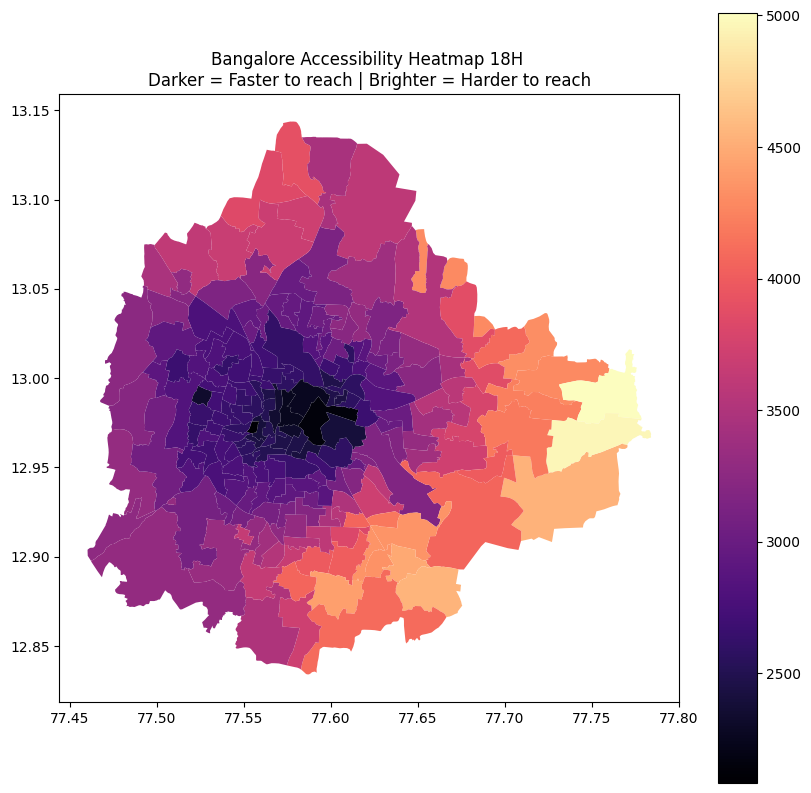

In [15]:
 # Merge the accessibility scores back to the full map
accessibility_map = wards.merge(ward_accessibility, left_on='MOVEMENT_ID', right_on='dstid')

# Plot
accessibility_map.plot(column='mean_travel_time', cmap='magma', legend=True, figsize=(10,10))
plt.title(f"Bangalore Accessibility Heatmap {hour_chosen}H \nDarker = Faster to reach | Brighter = Harder to reach")
plt.show()

#### You'll likely see a "Core vs. Periphery" pattern. Wards in the center usually have better average times because they are closer to everything, while outer wards like Whitefield or Electronics City will glow brightly (indicating high travel times).

In [16]:
# Filter for Katriguppe at 9 AM
kat_flow = rush_hour_data[rush_hour_data['dstid'] == target_id]

# Sort by travel time to find the furthest "origins"
furthest_origins = kat_flow.sort_values(by='mean_travel_time', ascending=False).head(10)

# Merge with ward names to see where these people are coming from
flow_analysis = furthest_origins.merge(wards[['MOVEMENT_ID', 'WARD_NAME']], left_on='sourceid', right_on='MOVEMENT_ID')
print("Longest Commutes INTO Katriguppe at 9 AM:")
print(flow_analysis[['WARD_NAME', 'mean_travel_time']])

Longest Commutes INTO Katriguppe at 9 AM:
          WARD_NAME  mean_travel_time
0           Hagadur           7395.36
1  Garudachar Playa           7003.96
2              Hudi           6950.67
3    Dodda Nekkundi           6512.65
4          Varthuru           6397.69
5         K R Puram           6074.13
6        Bellanduru           5903.57
7     Vijnana Nagar           5867.78
8      Basavanapura           5866.92
9      Marathahalli           5859.02


In [39]:
# !pip install folium matplotlib mapclassify

In [18]:
# Ensure we are using the 9 AM rush hour data for the whole city
rush_hour = data_csv[data_csv['hod'] == 9].copy()
rush_hour['mean_travel_min'] = (rush_hour['mean_travel_time'] / 60).round(2)

# Calculate the average accessibility for EVERY ward as a destination
avg_accessibility = rush_hour.groupby('dstid')['mean_travel_min'].mean().reset_index()

# Merge with your GeoDataFrame
accessibility_map = wards.merge(avg_accessibility, left_on='MOVEMENT_ID', right_on='dstid')

# Create the interactive map
# 'explore' is a wrapper for Folium within GeoPandas
m = accessibility_map.explore(
    column='mean_travel_min',  # Data to color the map by
    cmap='RdYlGn_r',           # Red (Slow) to Green (Fast)
    tooltip=['WARD_NAME', 'mean_travel_min'], # What shows when you hover
    popup=True,                # Click to see all data
    tiles="CartoDB positron",  # Clean, light background map
    legend_kwds=dict(colorbar=False), # Keeps the UI clean
    name="Bangalore Accessibility"
)

m # This displays the map in Jupyter

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import folium

# --- 1. DATA PREPARATION (Fixing the missing columns) ---
# Project for distance math
wards_m = wards.to_crs(epsg=32643)
centroids_m = wards_m.set_index('MOVEMENT_ID').geometry.centroid

def calculate_distance(row):
    try:
        # Match IDs and calculate distance in meters
        return centroids_m.loc[int(row['sourceid'])].distance(centroids_m.loc[int(row['dstid'])])
    except:
        return 0

# Ensure columns exist in the main dataframe to avoid KeyErrors
data_csv['dist_m'] = data_csv.apply(calculate_distance, axis=1)
data_csv['mean_travel_min'] = (data_csv['mean_travel_time'] / 60).round(2)
data_csv['dist_km'] = (data_csv['dist_m'] / 1000).round(2)
data_csv['avg_speed_kmh'] = (data_csv['dist_km'] / (data_csv['mean_travel_min'] / 60)).round(2)

# Prepare centroids for the line markers (Lat/Long)
centroids_wgs84 = wards.to_crs(epsg=4326).set_index('MOVEMENT_ID').geometry.centroid

# Pre-calculate the Accessibility Heatmap (9 AM averages)
rush_hour = data_csv[data_csv['hod'] == 9].copy()
avg_accessibility = rush_hour.groupby('dstid')['mean_travel_min'].mean().reset_index()
accessibility_map = wards.merge(avg_accessibility, left_on='MOVEMENT_ID', right_on='dstid')

# --- 2. WIDGET SETUP ---
origin_dd = widgets.Dropdown(options=sorted(wards['WARD_NAME'].unique()), description='Origin:')
dest_dd = widgets.Dropdown(options=sorted(wards['WARD_NAME'].unique()), description='Destination:')
button = widgets.Button(description="Analyze Trip", button_style='primary')
output = widgets.Output()

def update_combined_map(b):
    with output:
        clear_output(wait=True)
        
        id_start = wards[wards['WARD_NAME'] == origin_dd.value]['MOVEMENT_ID'].iloc[0]
        id_end = wards[wards['WARD_NAME'] == dest_dd.value]['MOVEMENT_ID'].iloc[0]
        
        # Initialize the base accessibility map
        m = accessibility_map.explore(
            column='mean_travel_min',
            cmap='RdYlGn_r',
            tooltip=['WARD_NAME', 'mean_travel_min'],
            tiles="CartoDB positron",
            legend_kwds=dict(colorbar=False),
            style_kwds=dict(fillOpacity=0.5)
        )
        
        # --- LOGIC FOR SAME SOURCE/DESTINATION ---
        if id_start == id_end:
            # Pull actual internal ward travel data
            internal_trip = rush_hour[(rush_hour['sourceid'] == id_start) & (rush_hour['dstid'] == id_end)]
            coord = [centroids_wgs84.loc[id_start].y, centroids_wgs84.loc[id_start].x]
            
            folium.Marker(coord, icon=folium.Icon(color='blue', icon='home'), 
                          popup="Internal Ward Trip").add_to(m)
            
            print(f"ANALYSIS: Internal travel within {origin_dd.value}")
            if not internal_trip.empty:
                print(f"Time: {internal_trip.iloc[0]['mean_travel_min']} mins | Distance: 0.0 km")
            else:
                print("No internal data recorded for this ward at 9 AM.")
        
        else:
            # Standard OD line logic
            trip = rush_hour[(rush_hour['sourceid'] == id_start) & (rush_hour['dstid'] == id_end)]
            
            if not trip.empty:
                stats = trip.iloc[0]
                speed = stats['avg_speed_kmh']
                line_color = "red" if speed < 12 else "orange" if speed < 25 else "green"
                
                start_coord = [centroids_wgs84.loc[id_start].y, centroids_wgs84.loc[id_start].x]
                end_coord = [centroids_wgs84.loc[id_end].y, centroids_wgs84.loc[id_end].x]
                
                folium.PolyLine([start_coord, end_coord], color=line_color, weight=10, opacity=0.9).add_to(m)
                folium.Marker(start_coord, icon=folium.Icon(color='green', icon='play')).add_to(m)
                folium.Marker(end_coord, icon=folium.Icon(color='red', icon='stop')).add_to(m)
                
                print(f"REPORT: {origin_dd.value} to {dest_dd.value}")
                print(f"Time: {stats['mean_travel_min']} mins | Distance: {stats['dist_km']} km | Speed: {speed} km/h")
            else:
                print("Warning: No Uber data recorded for this specific route at 9 AM.")

        m.fit_bounds(m.get_bounds())
        display(m)

button.on_click(update_combined_map)
display(widgets.VBox([widgets.HBox([origin_dd, dest_dd]), button]), output)

#### So the thing is, our data doesn't have any info on the exact number of vehicles (which we need for building the DT). So instead we'll use this relationship to infer demand
#### Travel Time  →  Speed  →  Traffic Density  →  Flow

##### Which OD pair appears most often

In [20]:
data_csv.groupby(['sourceid','dstid']).size().sort_values(ascending=False).head(10)

sourceid  dstid
100       86       24
118       151      24
112       20       24
          19       24
          16       24
          15       24
          13       24
          11       24
111       198      24
          188      24
dtype: int64

##### How many observations exist for each hour

In [21]:
data_csv['hod'].value_counts().sort_index()

hod
0     32261
1     28219
2     24056
3     24102
4     27599
5     30177
6     33690
7     35527
8     35772
9     36017
10    36332
11    36739
12    36624
13    36497
14    36660
15    36913
16    37231
17    37155
18    36828
19    36540
20    36131
21    36221
22    36091
23    34880
Name: count, dtype: int64

In [22]:
data_csv['avg_speed_kmh'].describe()

count    818262.000000
mean         17.163056
std           7.000348
min           0.000000
25%          12.120000
50%          15.360000
75%          20.790000
max         460.910000
Name: avg_speed_kmh, dtype: float64

##### Above has max speed of 460 which is obviously impossible so we'll clean the data

In [23]:
data_csv = data_csv[(data_csv['avg_speed_kmh'] > 3) & (data_csv['avg_speed_kmh'] < 80)]

In [24]:
data_csv['avg_speed_kmh'].describe()


count    817955.000000
mean         17.155568
std           6.887783
min           3.020000
25%          12.120000
50%          15.360000
75%          20.790000
max          79.840000
Name: avg_speed_kmh, dtype: float64

##### Now we'll look at rush hour statistics. Again, for now we've arbitrarily taken 9AM

In [25]:
rush_hour = data_csv[data_csv['hod'] == 9].copy()
rush_hour.shape

(36015, 11)

In [26]:
rush_hour[['sourceid','dstid']].drop_duplicates().shape

(36015, 2)

##### Building the OD Matrix

In [27]:
od_matrix = rush_hour.pivot_table(
    index="sourceid",
    columns="dstid",
    values="mean_travel_min"
)

od_matrix.shape

(198, 198)

##### Adding demand weight and normalising

In [28]:
rush_hour["demand_weight"] = 1 / rush_hour["mean_travel_min"]

In [29]:
rush_hour["demand_prob"] = rush_hour["demand_weight"] / rush_hour["demand_weight"].sum()

In [30]:
# Assuming you have an 'area_sqkm' or similar metric in your wards GDF
# If not, even using the Ward's total count of incoming records as a proxy works.

# Proxy for 'Attractiveness': How many total unique routes lead to this ward?
ward_popularity = rush_hour.groupby('dstid').size()

rush_hour['dst_popularity'] = rush_hour['dstid'].map(ward_popularity)

# New Gravity Formula: Popularity / Time
rush_hour["demand_weight"] = rush_hour['dst_popularity'] / rush_hour["mean_travel_min"]

# Re-run your Stochastic Sampling with this new weight...

In [31]:
rush_hour["demand_prob"].sum()

np.float64(1.0)

##### Basically this normalisation is to distribute traffic flow using probabilities. We don't have exact count but we have a rough approximation of how much percentage of traffic is associated with which OD pair

##### We'll assume the total number of vehicles to be some arbitrary number and simulate the traffic distribution

In [32]:
import numpy as np

TOTAL_VEHICLES = 10000

# STOCHASTIC SAMPLING:
# Randomly select 10,000 indices based on their demand probability
indices = np.random.choice(
    rush_hour.index, 
    size=TOTAL_VEHICLES, 
    p=rush_hour['demand_prob']
)

# Count how many times each index was picked
trip_counts = pd.Series(indices).value_counts()

# Map these counts back to your dataframe
rush_hour['trip_count'] = rush_hour.index.map(trip_counts).fillna(0).astype(int)

print(f"Total Vehicles: {rush_hour['trip_count'].sum()}")

Total Vehicles: 10000


#### Why we are doing this (The Logic)

1. The "Sparse Data" Problem: Our TOTAL_VEHICLES (10,000) is smaller than the total number of possible routes (~39,000). If we just multiply Probability×10,000, most routes get a tiny fraction (like 0.2 cars).

2. The Failure of Traditional Rounding: If we use int(), anything less than 1.0 becomes 0. We lose almost all our traffic because most routes have low probability.

3. The Stochastic Solution: Instead of "calculating" cars per route, we treat the city like a giant lottery. We "draw" 10,000 trips from the list of available routes, using the demand_prob as the weight. This ensures that:

    • The total number of trips is exactly 10,000.

    • Even "low-demand" routes have a fair, probabilistic chance of getting a car.

    • The "high-demand" routes naturally get picked more often.

In [33]:
# Force IDs to be integers so they match the Centroid Index
rush_hour["sourceid"] = rush_hour["sourceid"].astype(int)
rush_hour["dstid"] = rush_hour["dstid"].astype(int)

# Now run your mapping again
rush_hour["start_lat"] = rush_hour["sourceid"].map(lambda x: centroids_wgs84.loc[x].y)
rush_hour["start_lon"] = rush_hour["sourceid"].map(lambda x: centroids_wgs84.loc[x].x)
rush_hour["end_lat"] = rush_hour["dstid"].map(lambda x: centroids_wgs84.loc[x].y)
rush_hour["end_lon"] = rush_hour["dstid"].map(lambda x: centroids_wgs84.loc[x].x)

In [34]:
# Total hours spent by all 10,000 vehicles combined
total_hours = (rush_hour['trip_count'] * (rush_hour['mean_travel_min'] / 60)).sum()
print(f"Total travel time for 10,000 vehicles: {total_hours:.2f} hours")

Total travel time for 10,000 vehicles: 4951.29 hours


In [35]:
# Filter for only the routes that were selected in our stochastic lottery
active_trips = rush_hour[rush_hour['trip_count'] > 0][[
    "sourceid", 
    "dstid", 
    "trip_count", 
    "start_lat", 
    "start_lon", 
    "end_lat", 
    "end_lon"
]].sort_values(by="trip_count", ascending=True)

# Display the top rows
active_trips

,sourceid,dstid,trip_count,start_lat,start_lon,end_lat,end_lon
91,153,104,1,12.913501,77.556057,12.986798,77.533871
522140,181,37,1,12.900229,77.567014,13.001006,77.500975
521944,31,13,1,13.054436,77.515126,13.096250,77.623314
521671,7,31,1,13.001797,77.689122,13.054436,77.515126
521656,9,11,1,12.978493,77.681770,13.056595,77.558692
...,...,...,...,...,...,...,...
381224,114,43,6,12.971889,77.532844,12.995048,77.531584
801113,100,96,6,12.981565,77.575665,12.970688,77.577098
322000,107,51,7,12.991097,77.564195,12.997436,77.560514
809246,55,54,7,13.034054,77.593019,13.032555,77.586360


In [36]:
# 1. Create a dictionary that maps MOVEMENT_ID to WARD_NAME
ward_name_map = dict(zip(wards['MOVEMENT_ID'].astype(int), wards['WARD_NAME']))

# 2. Group active trips by destination and sum the vehicles
top_destinations = active_trips.groupby('dstid')['trip_count'].sum().reset_index()

# 3. Map the names to the IDs
top_destinations['ward_name'] = top_destinations['dstid'].map(ward_name_map)

# 4. Sort and look at the top 10
top_destinations = top_destinations.sort_values(by='trip_count', ascending=False)

print("--- TOP 25 DESTINATION WARDS (9 AM RUSH) ---")
print(top_destinations[['dstid', 'ward_name', 'trip_count']].head(25))

--- TOP 25 DESTINATION WARDS (9 AM RUSH) ---
     dstid                  ward_name  trip_count
39      40            Marappana Palya          79
108    109               Rajaji Nagar          78
101    102                 Okalipuram          75
113    114                Marenahalli          75
15      16                Kodigehalli          73
119    120                Vijayanagar          72
125    126           Deepanjali Nagar          72
124    125  Gali Anjenaya Temple ward          72
105    106              Sriramamandir          72
146    147              Hosakerehalli          72
150    151   Banashankari Temple ward          71
81      82          Sampangiram Nagar          71
53      54                Ganga Nagar          71
50      51             Gayithri Nagar          71
41      42           Mahalakshimpuram          71
129    130             Chalavadipalya          70
40      41                   Nagapura          70
107    108              Prakash Nagar          69
134  

In [37]:
# 1. Group by both source and destination to find the top specific corridors
top_corridors = active_trips.groupby(['sourceid', 'dstid', 'start_lat', 'start_lon', 'end_lat', 'end_lon'])['trip_count'].sum().reset_index()

# 2. Add Ward Names for both ends
top_corridors['origin_name'] = top_corridors['sourceid'].map(ward_name_map)
top_corridors['dest_name'] = top_corridors['dstid'].map(ward_name_map)

# 3. Pull in the average speed for these routes from our rush_hour data 
# (to prove they are slow and need a flyover)
top_corridors = top_corridors.merge(
    rush_hour[['sourceid', 'dstid', 'avg_speed_kmh', 'mean_travel_min']], 
    on=['sourceid', 'dstid'], 
    how='left'
)

# 4. Sort by trip_count and clean up the display
critical_links = top_corridors.sort_values(by='trip_count', ascending=False).reset_index(drop=True)

print("--- TOP 10 CRITICAL CORRIDORS (9 AM) ---")
print(critical_links[['origin_name', 'dest_name', 'trip_count', 'avg_speed_kmh']].head(10))

--- TOP 10 CRITICAL CORRIDORS (9 AM) ---
       origin_name                dest_name  trip_count  avg_speed_kmh
0          Hebbala              Ganga Nagar           7          28.28
1    Jaraganahalli            Yelchenahalli           7          19.60
2  Dayananda Nagar           Gayithri Nagar           7          18.41
3      Hongasandra          Mangammanapalya           6          18.95
4  Marappana Palya         Subramanya Nagar           6          29.03
5      Marenahalli        Govindaraja Nagar           6          16.26
6    Prakash Nagar           Gayithri Nagar           6           9.97
7      Chamrajapet           Chalavadipalya           6          17.60
8      Marenahalli  Shakthi Ganapathi Nagar           6          14.02
9        Jalahalli                 J P Park           6          22.85
